<a href="https://colab.research.google.com/github/sushant758/ML-Exercises/blob/main/kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [ ]:
df.shape

(188533, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,5083
engine,0
transmission,0
ext_col,0
int_col,0


In [ ]:
# First fill null values of fuel_type

In [ ]:
df['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,165940
Hybrid,6832
E85 Flex Fuel,5406
Diesel,3955
–,781
Plug-In Hybrid,521
not supported,15


In [ ]:
# before doing anything i have to remove '-' and not supported
df['fuel_type'] = df['fuel_type'].replace(['–' , 'not supported'], np.nan)

In [ ]:
df['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,165940
Hybrid,6832
E85 Flex Fuel,5406
Diesel,3955
Plug-In Hybrid,521


In [ ]:
# now check the skewness of the data then we will fill it
# print(df['fuel_type'].skew()) # i cant check its skewness bcz it is a categorical data

In [ ]:
df['fuel_type'].value_counts(normalize=True, dropna=False) * 100

,proportion
fuel_type,
Gasoline,88.016422
Hybrid,3.623769
NaN,3.118287
E85 Flex Fuel,2.867403
Diesel,2.097776
Plug-In Hybrid,0.276344


In [ ]:
df['fuel_type'].fillna(df['fuel_type'].mode()[0] , inplace=True)

In [ ]:
df.isnull().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0


In [ ]:
# Now fill the missing values for accident
# its a categorical column so i cant check its skewness so check its percentage
# here it seems that one is dominant so i will fill it with mode
df['accident'].value_counts(normalize=True, dropna=False) * 100

,proportion
accident,
None reported,76.651833
At least 1 accident or damage reported,22.047599
NaN,1.300568


In [ ]:
# since accident is an import feature so i will not remove it , instead i will create another column unknown
df['accident'] = df['accident'].fillna('Unknown')

In [ ]:
df['accident'].value_counts()

,count
accident,
None reported,144514
At least 1 accident or damage reported,41567
Unknown,2452


In [ ]:
# filling it with mode
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])

In [ ]:
df['accident'].isna().sum()

np.int64(0)

In [ ]:
# 0 means it get filled with mode

In [ ]:
# now its time to fill the clean_title feature
df['clean_title'].value_counts(normalize=True, dropna=False) * 100

,proportion
clean_title,
Yes,88.639124
NaN,11.360876


In [ ]:
df['clean_title'] = df['clean_title'].fillna('Unknown')

In [ ]:
df['clean_title'].value_counts()

,count
clean_title,
Yes,167114
Unknown,21419


In [ ]:
# Here no need to fill with mode NaN values gets filled with unknow

In [ ]:
df.isnull().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0


In [ ]:
# Now all the null values are clear

# Remove outliers

In [ ]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


<Axes: xlabel='brand', ylabel='Count'>

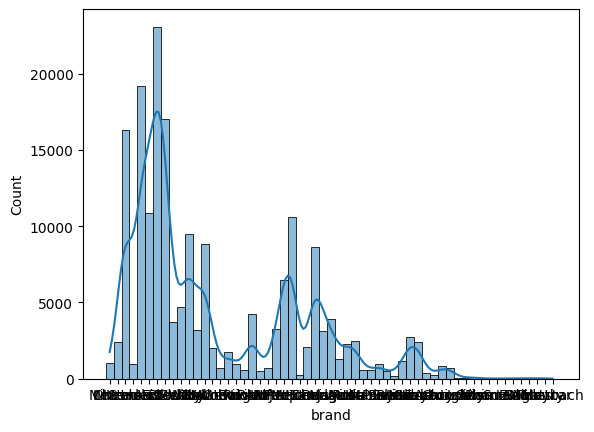

In [ ]:
sns.histplot(df['brand'], kde=True)

<Axes: xlabel='brand'>

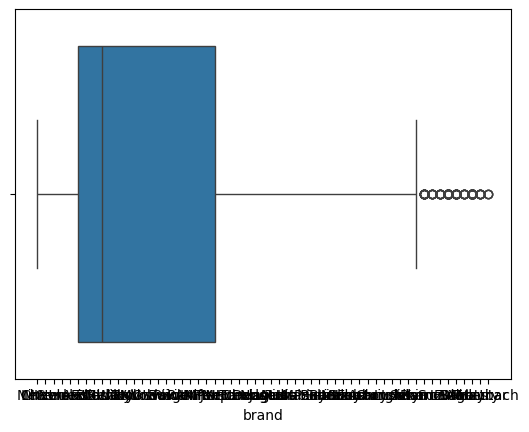

In [ ]:
sns.boxplot(x=df['brand'])

In [ ]:
df['brand'].value_counts()

,count
brand,
Ford,23088
Mercedes-Benz,19172
BMW,17028
Chevrolet,16335
Audi,10887
Porsche,10612
Land,9525
Toyota,8850
Lexus,8643


In [ ]:
# since brand is an important outlier , so dont remove it .
# instead of removing them i will keep them in a rare_brand column
counts = df['brand'].value_counts()

rare_brands = counts[counts < 10].index

df['brand'] = df['brand'].replace(rare_brands, 'Other')

In [ ]:
df['brand'].value_counts()

,count
brand,
Ford,23088
Mercedes-Benz,19172
BMW,17028
Chevrolet,16335
Audi,10887
Porsche,10612
Land,9525
Toyota,8850
Lexus,8643


<Axes: xlabel='model'>

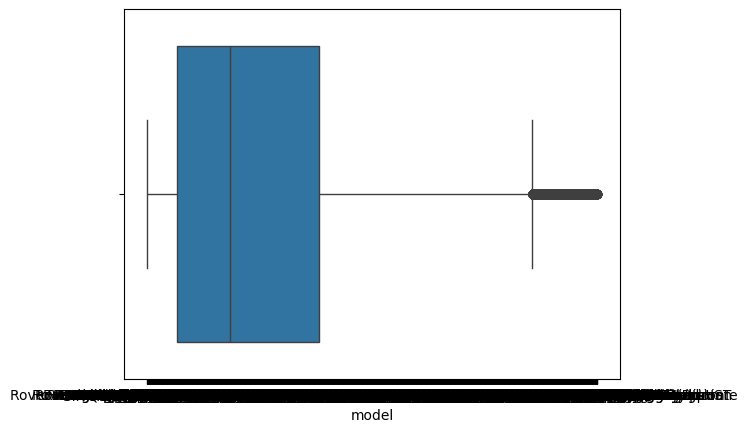

In [ ]:
# NOw checking for model
sns.boxplot(x=df['model'])

In [ ]:
df['model'].value_counts()

,count
model,
F-150 XLT,2945
M3 Base,2229
Camaro 2SS,1709
M4 Base,1622
Mustang GT Premium,1526
...,...
ForTwo Pure,2
XLR Base,1
X5 3.0i,1


In [ ]:
# instead of removing them i will keep them in a rare_model column
counts = df['model'].value_counts()

rare_model = counts[counts < 10].index

df['model'] = df['model'].replace(rare_model, 'Other')

In [ ]:
df['model'].value_counts()

,count
model,
F-150 XLT,2945
M3 Base,2229
Camaro 2SS,1709
M4 Base,1622
Mustang GT Premium,1526
...,...
MazdaSpeed Miata MX-5 Base,10
750 Li xDrive,10
X3 M AWD,10


In [ ]:
df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


<Axes: xlabel='model_year'>

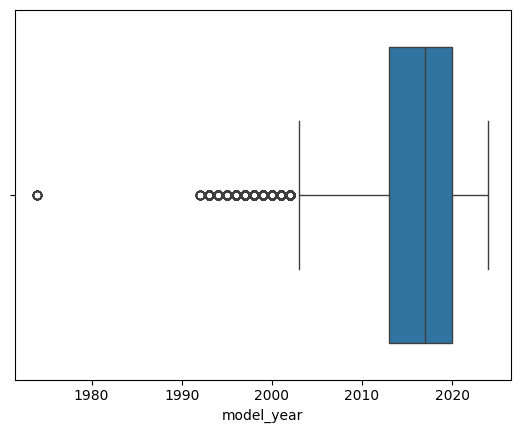

In [ ]:
# NOw checking for model_year
sns.boxplot(x=df['model_year'])

In [ ]:
print(df['model_year'].min())
print(df['model_year'].max())

1974
2024


In [ ]:
df = df[df['model_year'] != 1974]

In [ ]:
# removed it

<Axes: xlabel='model_year'>

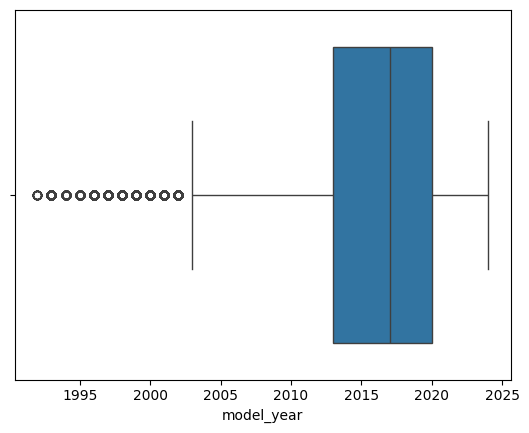

In [ ]:
# check
sns.boxplot(x=df['model_year'])

In [ ]:
# now changing the model_year into car_age
df['car_age'] = 2024 - df['model_year']

In [ ]:
df.drop('model_year', axis=1, inplace=True)

In [ ]:
df['car_age'].value_counts()

,count
car_age,
3,18198
6,16414
4,15848
2,15749
5,15409
8,13696
7,12794
9,11389
1,8769


<Axes: xlabel='milage'>

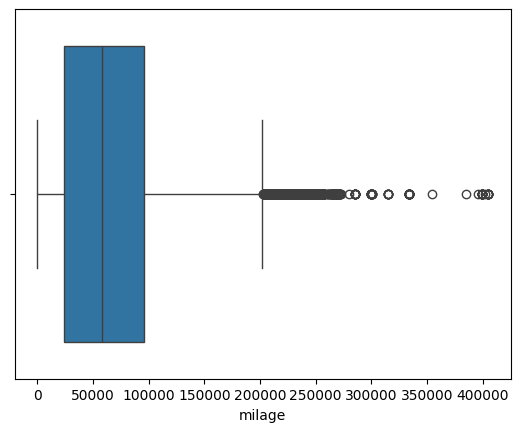

In [ ]:
# Now checking for milage
sns.boxplot(x=df['milage'])

In [ ]:
# check its skewness
print(df['milage'].skew())

0.8950706226255637


In [ ]:
# it 0.8893090637416279 is right skewed. so i will fill it with log
#df['milage'] = np.log1p(df['milage'])

In [ ]:
#sns.boxplot(x=df['milage'])

In [ ]:
#print(df['milage'].skew())

In [ ]:
# Mark that here it get more left skewed bcz it turn into negative .  so we will do median option

df['milage'] = df['milage'].fillna(df['milage'].median())

In [ ]:
print(df['milage'].skew())

0.8950706226255637


In [ ]:
# no change in skew value that normal

In [ ]:
df.head()

,id,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age
0,0,MINI,Cooper S Base,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200,17
1,1,Lincoln,LS V8,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999,22
2,2,Chevrolet,Silverado 2500 LT,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900,22
3,3,Genesis,G90 5.0 Ultimate,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000,7
4,4,Mercedes-Benz,Metris Base,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500,3


<Axes: xlabel='fuel_type'>

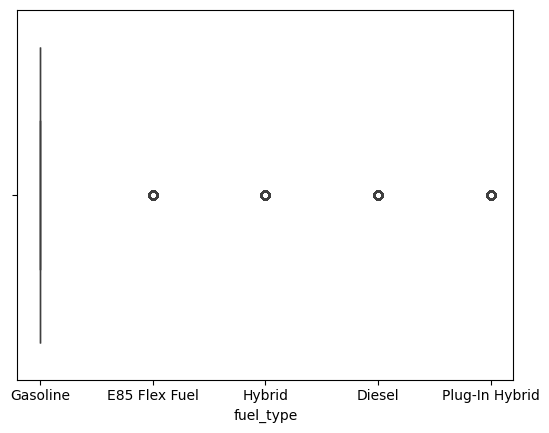

In [ ]:
# now checking for fuel_type
sns.boxplot(x=df['fuel_type'])

In [ ]:
df['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,171807
Hybrid,6832
E85 Flex Fuel,5406
Diesel,3955
Plug-In Hybrid,521


In [ ]:
# its a category not so outlier removing conncept doesnt work here

In [ ]:
# Now its time to work on engine
# first i will extract HP , No of litres, no of cylinder from the engine section and create their dummies . fuel is already defined .
# and drop the engine section

df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)

df['engine_liters'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)

df['cylinders'] = df['engine'].str.extract(r'(\d+)\sCylinder').astype(float)



df.drop('engine' , axis = 1 , inplace = True)

In [ ]:
df.head()

,id,brand,model,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,car_age,horsepower,engine_liters,cylinders
0,0,MINI,Cooper S Base,213000,Gasoline,A/T,Yellow,Gray,None reported,Yes,4200,17,172.0,1.6,4.0
1,1,Lincoln,LS V8,143250,Gasoline,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999,22,252.0,3.9,8.0
2,2,Chevrolet,Silverado 2500 LT,136731,E85 Flex Fuel,A/T,Blue,Gray,None reported,Yes,13900,22,320.0,5.3,8.0
3,3,Genesis,G90 5.0 Ultimate,19500,Gasoline,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000,7,420.0,5.0,8.0
4,4,Mercedes-Benz,Metris Base,7388,Gasoline,7-Speed A/T,Black,Beige,None reported,Yes,97500,3,208.0,2.0,4.0


In [ ]:
# now i will check , if there is any null or duplicated values in the new dummies of engine
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188521 entries, 0 to 188532
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             188521 non-null  int64  
 1   brand          188521 non-null  object 
 2   model          188521 non-null  object 
 3   milage         188521 non-null  int64  
 4   fuel_type      188521 non-null  object 
 5   transmission   188521 non-null  object 
 6   ext_col        188521 non-null  object 
 7   int_col        188521 non-null  object 
 8   accident       188521 non-null  object 
 9   clean_title    188521 non-null  object 
 10  price          188521 non-null  int64  
 11  car_age        188521 non-null  int64  
 12  horsepower     155272 non-null  float64
 13  engine_liters  174317 non-null  float64
 14  cylinders      150676 non-null  float64
dtypes: float64(3), int64(4), object(8)
memory usage: 23.0+ MB


In [ ]:
# found null values in horsepower , engine_liters and cylinders

<Axes: xlabel='horsepower'>

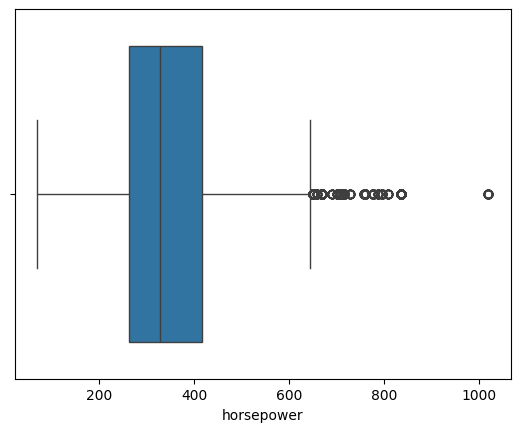

In [ ]:
sns.boxplot(x=df['horsepower'])

In [ ]:
print(df['horsepower'].skew())

0.7804494710124396


In [ ]:
# This is moderately right-skewed.
# I wil fill it using median

df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [ ]:
df['horsepower'].isna().sum()

np.int64(0)

<Axes: xlabel='engine_liters'>

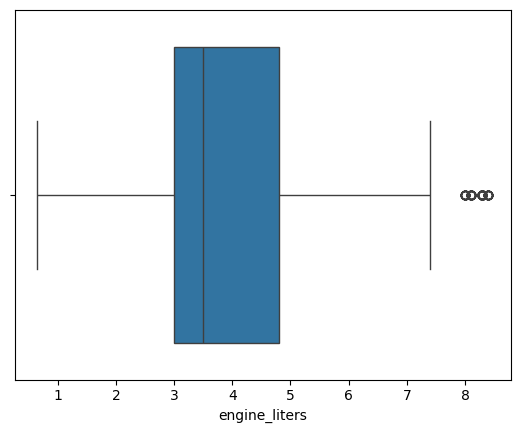

In [ ]:
# Now fill the engine_liters null value
# first check skewed value and graph
sns.boxplot(x=df['engine_liters'])

In [ ]:
print(df['engine_liters'].skew())

0.459038552911639


In [ ]:
# it is is close to symmetric. so i will fill it with mean()
df['engine_liters'] = df['engine_liters'].fillna(df['engine_liters'].mean())

In [ ]:
df['engine_liters'].isna().sum()

np.int64(0)

<Axes: xlabel='cylinders'>

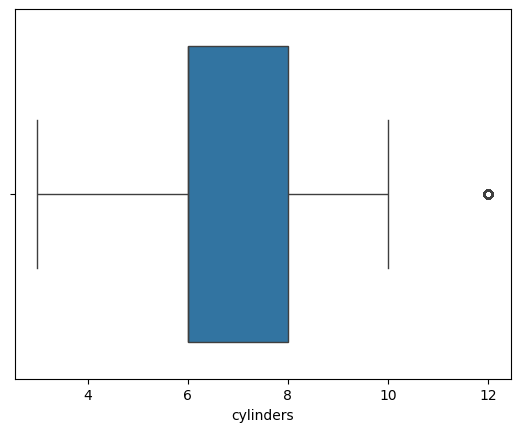

In [ ]:
# Now its time for cylinders
sns.boxplot(x=df['cylinders'])

In [ ]:
df['cylinders'].min()

3.0

In [ ]:
df['cylinders'].max()

12.0

In [ ]:
df['cylinders'].skew()

np.float64(0.1500630456164165)

In [ ]:
# This is very close to symmetric , so i will fill it with median
df['cylinders'] = df['cylinders'].fillna(df['cylinders'].median())

In [ ]:
df['cylinders'].isna().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188521 entries, 0 to 188532
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             188521 non-null  int64  
 1   brand          188521 non-null  object 
 2   model          188521 non-null  object 
 3   milage         188521 non-null  int64  
 4   fuel_type      188521 non-null  object 
 5   transmission   188521 non-null  object 
 6   ext_col        188521 non-null  object 
 7   int_col        188521 non-null  object 
 8   accident       188521 non-null  object 
 9   clean_title    188521 non-null  object 
 10  price          188521 non-null  int64  
 11  car_age        188521 non-null  int64  
 12  horsepower     188521 non-null  float64
 13  engine_liters  188521 non-null  float64
 14  cylinders      188521 non-null  float64
dtypes: float64(3), int64(4), object(8)
memory usage: 23.0+ MB


In [ ]:
df.head()

,id,brand,model,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,car_age,horsepower,engine_liters,cylinders
0,0,MINI,Cooper S Base,213000,Gasoline,A/T,Yellow,Gray,None reported,Yes,4200,17,172.0,1.6,4.0
1,1,Lincoln,LS V8,143250,Gasoline,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999,22,252.0,3.9,8.0
2,2,Chevrolet,Silverado 2500 LT,136731,E85 Flex Fuel,A/T,Blue,Gray,None reported,Yes,13900,22,320.0,5.3,8.0
3,3,Genesis,G90 5.0 Ultimate,19500,Gasoline,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000,7,420.0,5.0,8.0
4,4,Mercedes-Benz,Metris Base,7388,Gasoline,7-Speed A/T,Black,Beige,None reported,Yes,97500,3,208.0,2.0,4.0


<Axes: xlabel='transmission'>

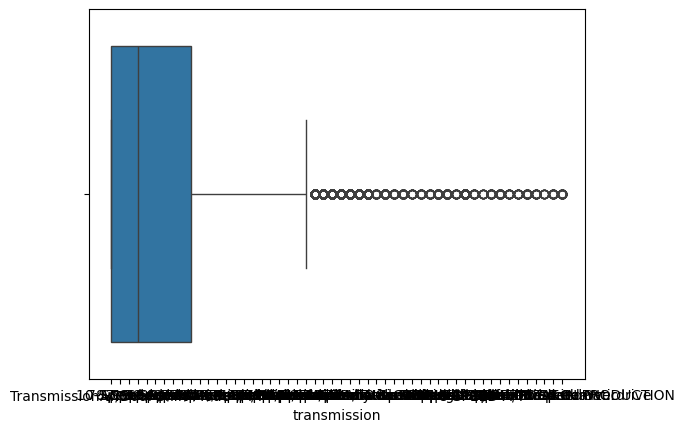

In [ ]:
# Now its time for cylinders
sns.boxplot(x=df['transmission'])

In [ ]:
# its not numerical data so we cant check skewness so i will check percentage
df['transmission'].value_counts(normalize=True, dropna=False) * 100

,proportion
transmission,
A/T,26.469200
8-Speed A/T,10.951035
Transmission w/Dual Shift Mode,10.213716
6-Speed A/T,9.571347
6-Speed M/T,6.363747
7-Speed A/T,5.900669
Automatic,5.670456
8-Speed Automatic,4.472181
10-Speed A/T,4.266899


In [ ]:
# '–', '2', 'F', 'SCHEDULED FOR OR IN PRODUCTION' these are not of use so i will replace them .
unknown_transmission = ['–', '2', 'F', 'SCHEDULED FOR OR IN PRODUCTION']

df['transmission'] = df['transmission'].replace(unknown_transmission, np.nan)

In [ ]:
# now i will check if there is any Nan values
df['transmission'].isnull().sum()

np.int64(245)

In [ ]:
# now i will fill them using mode
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

In [ ]:
df['transmission'].isnull().sum()

np.int64(0)

<Axes: xlabel='ext_col'>

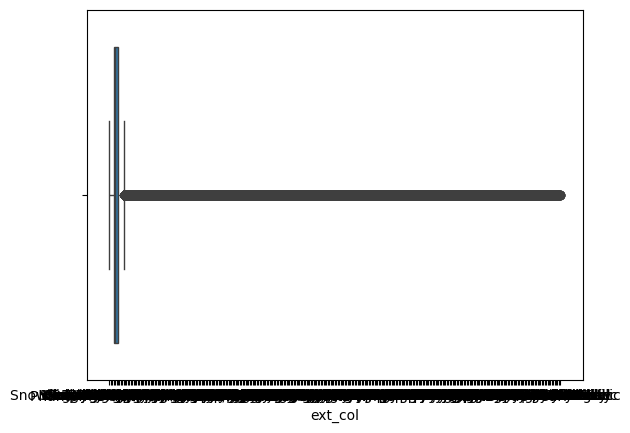

In [ ]:
# Now checking for ext_col
sns.boxplot(x=df['ext_col'])

In [ ]:
df['ext_col'].value_counts(normalize=True, dropna=False) * 100

,proportion
ext_col,
Black,25.808796
White,23.240912
Gray,13.414951
Silver,9.014911
Blue,7.720095
...,...
Granite Crystal Metallic Clearcoat,0.002652
GT SILVER,0.002652
Blue Caelum,0.002652


In [ ]:
df['ext_col'].isna().sum()

np.int64(0)

In [ ]:
# no need to do something at here

<Axes: xlabel='int_col'>

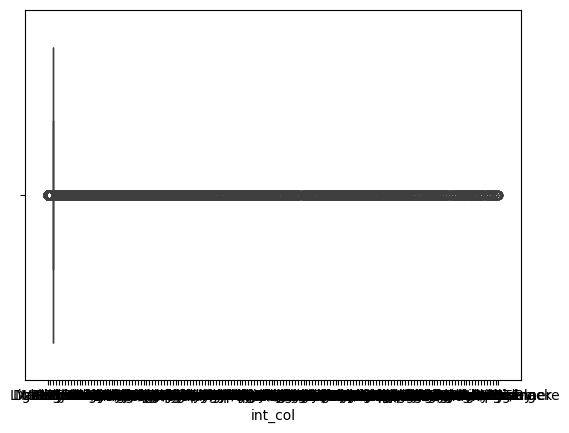

In [ ]:
# Now checking for int_col
sns.boxplot(x=df['int_col'])

In [ ]:
# no need to do any thing

<Axes: xlabel='accident'>

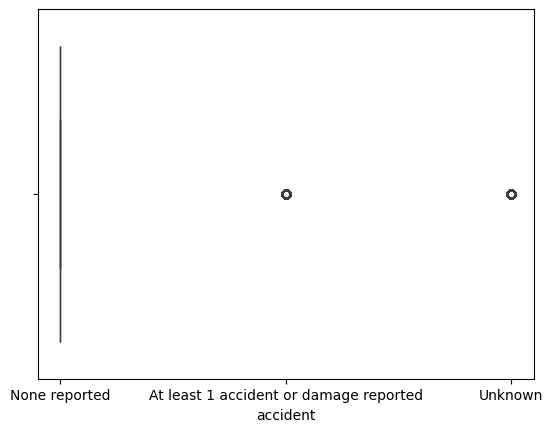

In [ ]:
# now checking for accident
sns.boxplot(x=df['accident'])

In [ ]:
df['accident'].value_counts()

,count
accident,
None reported,144504
At least 1 accident or damage reported,41567
Unknown,2450


In [ ]:
# i will remove the None reporte
df['accident'] = df['accident'].replace(
    'None reporte',
    'None reported'
)

In [ ]:
# now check how it is distributed
df['accident'].value_counts(normalize=True, dropna=False) * 100

,proportion
accident,
None reported,76.651408
At least 1 accident or damage reported,22.049002
Unknown,1.299590


In [ ]:
# since it is an important factor , so i will not remove it , instead of removing , i will make dummies , and drop the original accident
df = pd.get_dummies(df, columns=['accident'], drop_first=True, dtype=int)

In [ ]:
df.head()

,id,brand,model,milage,fuel_type,transmission,ext_col,int_col,clean_title,price,car_age,horsepower,engine_liters,cylinders,accident_None reported,accident_Unknown
0,0,MINI,Cooper S Base,213000,Gasoline,A/T,Yellow,Gray,Yes,4200,17,172.0,1.6,4.0,1,0
1,1,Lincoln,LS V8,143250,Gasoline,A/T,Silver,Beige,Yes,4999,22,252.0,3.9,8.0,0,0
2,2,Chevrolet,Silverado 2500 LT,136731,E85 Flex Fuel,A/T,Blue,Gray,Yes,13900,22,320.0,5.3,8.0,1,0
3,3,Genesis,G90 5.0 Ultimate,19500,Gasoline,Transmission w/Dual Shift Mode,Black,Black,Yes,45000,7,420.0,5.0,8.0,1,0
4,4,Mercedes-Benz,Metris Base,7388,Gasoline,7-Speed A/T,Black,Beige,Yes,97500,3,208.0,2.0,4.0,1,0


<Axes: xlabel='clean_title'>

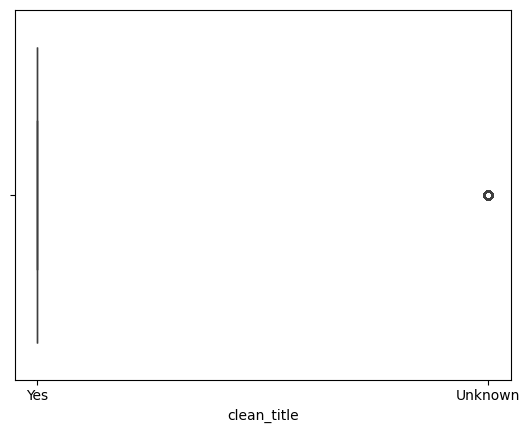

In [ ]:
# now check for clean_title
sns.boxplot(x=df['clean_title'])

In [ ]:
df['clean_title'] = df['clean_title'].map({'Yes' : 1 , 'Unknown' : 0})

In [ ]:
df.head()

,id,brand,model,milage,fuel_type,transmission,ext_col,int_col,clean_title,price,car_age,horsepower,engine_liters,cylinders,accident_None reported,accident_Unknown
0,0,MINI,Cooper S Base,213000,Gasoline,A/T,Yellow,Gray,1,4200,17,172.0,1.6,4.0,1,0
1,1,Lincoln,LS V8,143250,Gasoline,A/T,Silver,Beige,1,4999,22,252.0,3.9,8.0,0,0
2,2,Chevrolet,Silverado 2500 LT,136731,E85 Flex Fuel,A/T,Blue,Gray,1,13900,22,320.0,5.3,8.0,1,0
3,3,Genesis,G90 5.0 Ultimate,19500,Gasoline,Transmission w/Dual Shift Mode,Black,Black,1,45000,7,420.0,5.0,8.0,1,0
4,4,Mercedes-Benz,Metris Base,7388,Gasoline,7-Speed A/T,Black,Beige,1,97500,3,208.0,2.0,4.0,1,0


<Axes: xlabel='price'>

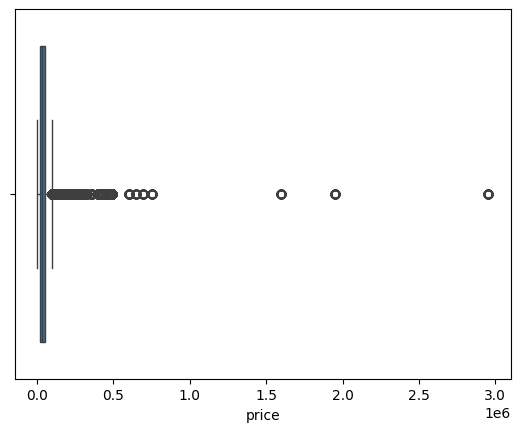

In [ ]:
# now check for price
sns.boxplot(x=df['price'])

In [ ]:
# it is right skewed so i will fill it with

In [ ]:
print(df['price'].skew())

20.26941033624218


In [ ]:
df['price'].isnull().sum()

np.int64(0)

In [ ]:
# i will fill this null value first
df['price'] = df['price'].fillna(df['price'].median())

# then i will fill it with log , bcz it is a numerical feature
df['price_log'] = np.log1p(df['price'])

In [ ]:
# and drop the original
X_test = test_df.drop('price', axis=1)

NameError: name 'test_df' is not defined

In [ ]:
df.head()